# XGBoost v1 (Flights Only)

This notebook:

1. Loads the merged flight + weather dataset
2. Uses only basic flight features (no weather)
3. Trains a simple **multiclass** XGBoost on flight data ------> `**Baseline**`
4. Performs a hyperparameter grid search
5. Compares both model performance

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, average_precision_score,
                             ConfusionMatrixDisplay)
from xgboost import XGBClassifier


plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

Loading the data and building targets.

In [7]:
sys.path.append('../../../4_scripts')
from flight_weather_setup import load_data, FEATURES

df = load_data()

features = ['Airline', 'Origin', 'Month', 'DayOfWeek', 'dep_hour', 'Distance']
features = [f for f in features if f in df.columns]

train = df[df['split'] == 'train']
val   = df[df['split'] == 'val']
test  = df[df['split'] == 'test']

X_train, y_train = train[features], train['target'].astype(int)
X_val,   y_val   = val[features],   val['target'].astype(int)
X_test,  y_test  = test[features],  test['target'].astype(int)

if len(X_train) > 2_000_000:
    idx = np.random.choice(len(X_train), 2_000_000, replace=False)
    X_train = X_train.iloc[idx]
    y_train = y_train.iloc[idx]

print(f'train: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}')

shape: (24165691, 26)
target
on_time      19218827
delayed       4470681
cancelled      476183
Name: count, dtype: int64


## Feature Selection

Using just the basic flight data

In [8]:
for col in ['Airline','Origin','region']:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

features = ['Airline', 'Origin', 'Month', 'DayOfWeek', 'dep_hour', 'Distance']
features = [f for f in features if f in df.columns]

train = df[df['split']=='train']
val   = df[df['split']=='val']
test  = df[df['split']=='test']

X_train, y_train = train[features], train['target']
X_val,   y_val   = val[features],   val['target']
X_test,  y_test  = test[features],  test['target']

print(f'train: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}')

train: (13777101, 6), val: (6310951, 6), test: (4077639, 6)


In [9]:
# cap training set to 2M for faster iteration
if len(train) > 2_000_000:
    train = train.sample(2_000_000, random_state=42)
    print(f'training capped to {len(train):,} rows')

training capped to 2,000,000 rows


## Training

Starting simple, just training with reasonable params as a baseline.Just want to see where we're starting from before we start making changes.

In [10]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
model.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_class=3, ...)


val macro F1: 0.3054
              precision    recall  f1-score   support

     on_time       0.81      1.00      0.90   5127027
     delayed       0.53      0.01      0.02   1072910
   cancelled       0.00      0.00      0.00    111014

    accuracy                           0.81   6310951
   macro avg       0.45      0.34      0.31   6310951
weighted avg       0.75      0.81      0.73   6310951



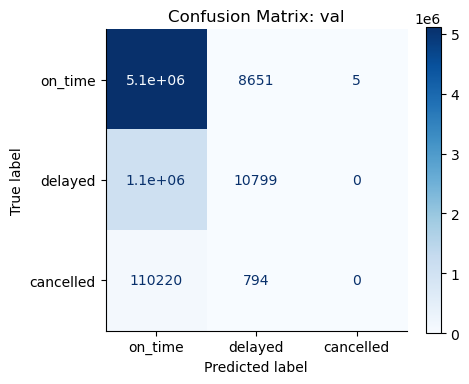

In [11]:
def evaluate(model, X, y_true, label='val'):
    y_pred = model.predict(X)
    mf1 = f1_score(y_true, y_pred, average='macro')
    print(f'\n{label} macro F1: {mf1:.4f}')
    print(classification_report(y_true, y_pred,
          target_names=['on_time','delayed','cancelled'], zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5,4))
    disp = ConfusionMatrixDisplay(cm, display_labels=['on_time','delayed','cancelled'])
    disp.plot(ax=ax, colorbar=True, cmap='Blues')
    ax.set_title(f'Confusion Matrix: {label}')
    plt.tight_layout()
    plt.show()
    return mf1
mf1_val = evaluate(model, X_val, y_val, 'val')

## Feature Importance

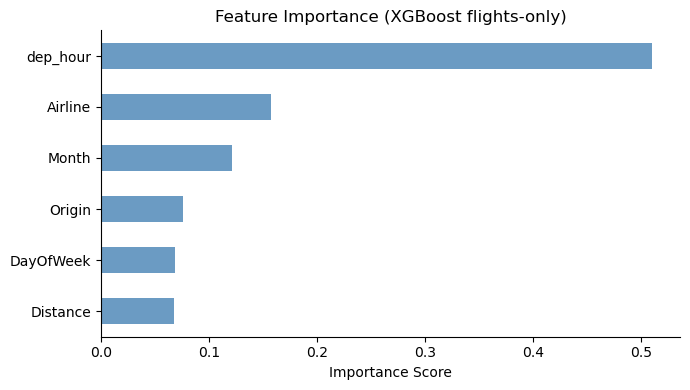

In [12]:
fig, ax = plt.subplots(figsize=(7,4))
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
importance.plot(kind='barh', color='steelblue', alpha=0.8, ax=ax)
ax.set_title('Feature Importance (XGBoost flights-only)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Test Set Results


test macro F1: 0.2954
              precision    recall  f1-score   support

     on_time       0.76      1.00      0.86   3091391
     delayed       0.53      0.01      0.02    863057
   cancelled       0.00      0.00      0.00    123191

    accuracy                           0.76   4077639
   macro avg       0.43      0.34      0.30   4077639
weighted avg       0.69      0.76      0.66   4077639



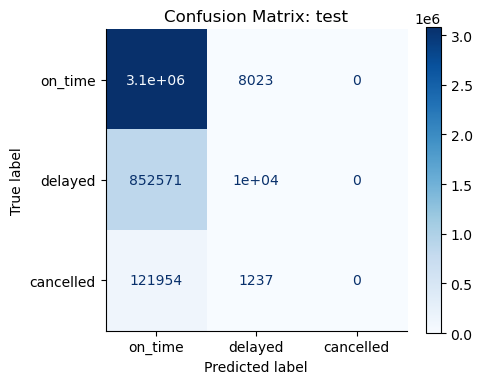

In [13]:
mf1_test = evaluate(model, X_test, y_test, 'test')

In [16]:
print('v1 results:')
print(f'  val  macro F1: {mf1_val:.4f}')
print(f'  test macro F1: {mf1_test:.4f}')

v1 results:
  val  macro F1: 0.3054
  test macro F1: 0.2954


## Grid Search Exploration

Ran 50 random param combos to find something better than the baseline. We tracked cancelled recall specifically since that's the main thing the baseline was failing at.

Deeper models (depth=6) kept getting higher overall accuracy but basically 0% cancelled recall, which isn't useful at all. Iteration 7 was the sweet spot (depth=4, lr=0.04, trees=500, alpha=0.8, lambda=2.0) with 47.75% cancelled recall and only a 0.047 gap. We'll use these params in the retrain below to see if they hold up on the full dataset.

In [ ]:
# grid search: 
param_grid = {
    'n_estimators': [500, 700, 900],
    'max_depth': [4, 5, 6],
    'learning_rate': [0.04, 0.05, 0.06, 0.07],
    'subsample': [0.7, 0.75, 0.8],
    'colsample_bytree': [0.7, 0.75, 0.8],
    'reg_alpha': [0.3, 0.5, 0.8, 1.0],
    'reg_lambda': [0.8, 1.0, 1.5, 2.0],
    'min_child_weight': [6, 8, 10],
    'gamma': [0.1, 0.15, 0.2]
}

n_tries = 50
results = []

print(f"Testing {n_tries} random combinations\n")

for i in range(n_tries):
    params = {k: np.random.choice(v) for k, v in param_grid.items()}
    import time
    t0 = time.time()
    m = XGBClassifier(**params, objective='multi:softmax', num_class=3,
                      random_state=42, n_jobs=-1, verbosity=0)
    idx = np.random.choice(len(X_train), 200_000, replace=False)
    X_train_gs, y_train_gs = X_train.iloc[idx], y_train.iloc[idx]
    m.fit(X_train_gs, y_train_gs, eval_set=[(X_val, y_val)], verbose=False)
    elapsed = time.time() - t0
    y_pred_test = m.predict(X_test)
    test_acc = (y_pred_test == y_test.values).mean()
    from sklearn.metrics import balanced_accuracy_score
    bal_acc = balanced_accuracy_score(y_test, y_pred_test)
    canc_mask = y_test == 2
    canc_recall = (y_pred_test[canc_mask] == 2).mean() if canc_mask.sum() > 0 else 0
    gap = test_acc - bal_acc
    results.append({**params, 'iter': i+1, 'test_acc': test_acc,
                    'bal_acc': bal_acc, 'canc_recall': canc_recall, 'gap': gap})
    print(f"[{i+1}/50] depth={params['max_depth']}, lr={params['learning_rate']}, "
          f"trees={params['n_estimators']}, alpha={params['reg_alpha']}, lambda={params['reg_lambda']}")
    print(f"  Test: {test_acc:.4f}, Balanced: {bal_acc:.4f}, "
          f"Cancelled: {canc_recall*100:.2f}%, Gap: {gap:.4f} ({elapsed:.1f}s)\n")

Testing 50 random combinations

[1/50] depth=5, lr=0.05, trees=700, alpha=1.0, lambda=1.0
  Test: 0.5909, Balanced: 0.5215, Cancelled: 39.96%, Gap: 0.1005 (19.8s)

[2/50] depth=6, lr=0.07, trees=700, alpha=1.0, lambda=0.8
  Test: 0.6113, Balanced: 0.5076, Cancelled: 30.74%, Gap: 0.1725 (20.7s)

[3/50] depth=4, lr=0.07, trees=700, alpha=0.8, lambda=1.5
  Test: 0.5819, Balanced: 0.5214, Cancelled: 42.01%, Gap: 0.0836 (19.4s)

[4/50] depth=5, lr=0.06, trees=700, alpha=0.8, lambda=2.0
  Test: 0.5977, Balanced: 0.5213, Cancelled: 38.32%, Gap: 0.1117 (20.0s)

[5/50] depth=4, lr=0.05, trees=700, alpha=0.8, lambda=1.5
  Test: 0.5722, Balanced: 0.5198, Cancelled: 43.65%, Gap: 0.0701 (19.1s)

[6/50] depth=5, lr=0.05, trees=500, alpha=0.5, lambda=2.0
  Test: 0.5880, Balanced: 0.5245, Cancelled: 41.80%, Gap: 0.0824 (14.2s)

[7/50] depth=4, lr=0.04, trees=500, alpha=0.8, lambda=2.0
  Test: 0.5640, Balanced: 0.5259, Cancelled: 47.75%, Gap: 0.0475 (13.7s)

[8/50] depth=4, lr=0.06, trees=700, alpha=1.

## Retrain with Best Params

Iteration 7 stood out because it had the highest cancelled recall (47.75%) while keeping the gap between test accuracy and balanced accuracy really small (0.047). Every other iteration either had decent accuracy but terrible cancelled recall, or too big of a gap. So let's see if these params actually hold up on the full dataset.


val  (grid search) macro F1: 0.2998
              precision    recall  f1-score   support

     on_time       0.81      1.00      0.90   5127027
     delayed       0.62      0.00      0.00   1072910
   cancelled       0.00      0.00      0.00    111014

    accuracy                           0.81   6310951
   macro avg       0.48      0.33      0.30   6310951
weighted avg       0.77      0.81      0.73   6310951



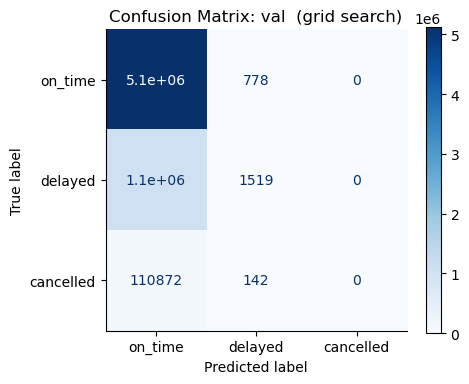


test (grid search) macro F1: 0.2885
              precision    recall  f1-score   support

     on_time       0.76      1.00      0.86   3091391
     delayed       0.58      0.00      0.00    863057
   cancelled       0.00      0.00      0.00    123191

    accuracy                           0.76   4077639
   macro avg       0.45      0.33      0.29   4077639
weighted avg       0.70      0.76      0.65   4077639



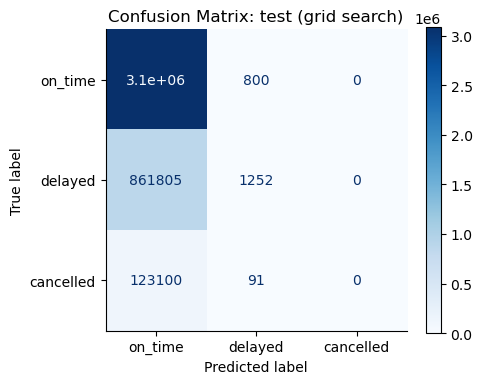

In [14]:
# retrain using best params from grid search (iteration 7)
model_gs = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.04,
    reg_alpha=0.8,
    reg_lambda=2.0,
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
model_gs.fit(X_train, y_train,
             eval_set=[(X_val, y_val)],
             verbose=False)

mf1_val_gs  = evaluate(model_gs, X_val,  y_val,  'val  (grid search)')
mf1_test_gs = evaluate(model_gs, X_test, y_test, 'test (grid search)')

## Baseline vs Grid Search

         model  depth   lr  alpha  lambda  val macro F1  test macro F1
   v1 baseline      6 0.10    0.0     1.0        0.3054         0.2954
v1 grid search      4 0.04    0.8     2.0        0.2998         0.2885


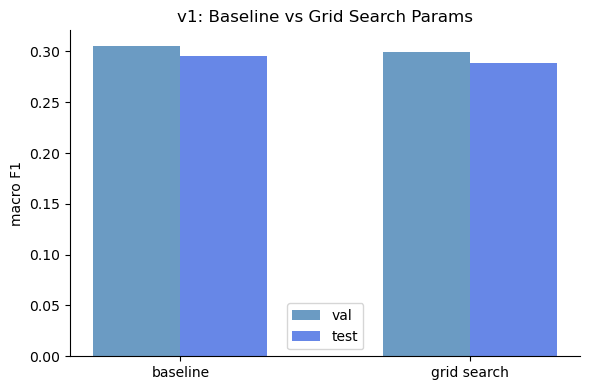

In [15]:
comparison = pd.DataFrame({
    'model':          ['v1 baseline', 'v1 grid search'],
    'depth':          [6, 4],
    'lr':             [0.1, 0.04],
    'alpha':          [0.0, 0.8],
    'lambda':         [1.0, 2.0],
    'val macro F1':   [round(mf1_val,  4), round(mf1_val_gs,  4)],
    'test macro F1':  [round(mf1_test, 4), round(mf1_test_gs, 4)],
})
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(2)
width = 0.3
ax.bar(x - width/2, [mf1_val,    mf1_val_gs],  width, label='val',  color='steelblue', alpha=0.8)
ax.bar(x + width/2, [mf1_test,   mf1_test_gs], width, label='test', color='royalblue', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(['baseline', 'grid search'])
ax.set_ylabel('macro F1')
ax.set_title('v1: Baseline vs Grid Search Params')
ax.legend()
plt.tight_layout()
plt.show()

## Summary

The baseline and grid search models both completely miss cancellations (0% recall). Even after tuning the hyperparameters, the model just predicts everything as on-time because that's what 76% of the data is. 
Tuning alone isn't going to fix this.

Next up we'll add weather features and see if that makes a difference.